In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned ACN Caltech dataset
df = pd.read_csv("../Data/processed/acn_caltech_2019_clean.csv")

# Restore local timestamp
df["connectionTime_local"] = pd.to_datetime(
    df["connectionTime_local"],
    utc=True
).dt.tz_convert("America/Los_Angeles")

print("Dataset shape:", df.shape)
print("Date range:")
print(df["connectionTime_local"].min())
print(df["connectionTime_local"].max())

Dataset shape: (10607, 24)
Date range:
2019-01-01 09:41:45-08:00
2019-12-30 15:29:51-08:00


In [2]:
# Create local calendar date
df["date"] = df["connectionTime_local"].dt.date

# Aggregate all charging sessions that started on each day
daily = (
    df.groupby("date")
      .agg(
          total_energy_kWh=("kWhDelivered", "sum"),
          sessions=("sessionID", "count")
      )
      .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])

print("Daily dataset shape:", daily.shape)
daily.head(10)

Daily dataset shape: (363, 3)


,date,total_energy_kWh,sessions
0,2019-01-01,48.802,8
1,2019-01-02,487.445,34
2,2019-01-03,329.244,32
3,2019-01-04,318.916,29
4,2019-01-05,93.990,16
5,2019-01-06,180.656,14
6,2019-01-07,559.365,38
7,2019-01-08,387.251,40
8,2019-01-09,344.216,39
9,2019-01-10,335.086,38


In [3]:
# Create a complete calendar from the first to last date
full_dates = pd.date_range(
    start=daily["date"].min(),
    end=daily["date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(daily["date"])

print("First date:", daily["date"].min())
print("Last date:", daily["date"].max())
print("Expected calendar days:", len(full_dates))
print("Days present:", len(daily))
print("Missing dates:", len(missing_dates))
print("\nMissing dates:")
print(missing_dates)

First date: 2019-01-01 00:00:00
Last date: 2019-12-30 00:00:00
Expected calendar days: 364
Days present: 363
Missing dates: 1

Missing dates:
DatetimeIndex(['2019-12-25'], dtype='datetime64[s]', freq='D')


In [4]:
# Reindex to include every calendar day in our observed period
daily = (
    daily.set_index("date")
         .reindex(full_dates, fill_value=0)
         .rename_axis("date")
         .reset_index()
)

print("Daily dataset shape:", daily.shape)

print("\nDecember 25:")
print(daily[daily["date"] == "2019-12-25"])

print("\nAny remaining missing dates?")
print(daily["date"].diff().dropna().value_counts().head())


Daily dataset shape: (364, 3)

December 25:
          date  total_energy_kWh  sessions
358 2019-12-25               0.0         0

Any remaining missing dates?
date
1 days    363
Name: count, dtype: int64


In [5]:
# Calendar features
daily["day_of_week"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["is_weekend"] = (daily["day_of_week"] >= 5).astype(int)

# Historical demand features
daily["energy_lag_1"] = daily["total_energy_kWh"].shift(1)
daily["energy_lag_7"] = daily["total_energy_kWh"].shift(7)

# Historical rolling demand
daily["energy_rolling_7"] = (
    daily["total_energy_kWh"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily[
    [
        "date",
        "total_energy_kWh",
        "day_of_week",
        "month",
        "is_weekend",
        "energy_lag_1",
        "energy_lag_7",
        "energy_rolling_7"
    ]
].head(10)

,date,total_energy_kWh,day_of_week,month,is_weekend,energy_lag_1,energy_lag_7,energy_rolling_7
0,2019-01-01,48.802,1,1,0,NaN,NaN,NaN
1,2019-01-02,487.445,2,1,0,48.802,NaN,NaN
2,2019-01-03,329.244,3,1,0,487.445,NaN,NaN
3,2019-01-04,318.916,4,1,0,329.244,NaN,NaN
4,2019-01-05,93.990,5,1,1,318.916,NaN,NaN
5,2019-01-06,180.656,6,1,1,93.990,NaN,NaN
6,2019-01-07,559.365,0,1,0,180.656,NaN,NaN
7,2019-01-08,387.251,1,1,0,559.365,48.802,288.345429
8,2019-01-09,344.216,2,1,0,387.251,487.445,336.695286
9,2019-01-10,335.086,3,1,0,344.216,329.244,316.234000


In [6]:
ml_data = daily.dropna().copy()

features = [
    "day_of_week",
    "month",
    "is_weekend",
    "energy_lag_1",
    "energy_lag_7",
    "energy_rolling_7"
]

target = "total_energy_kWh"

X = ml_data[features]
y = ml_data[target]

print("ML dataset shape:", ml_data.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

ML dataset shape: (357, 9)
Feature matrix shape: (357, 6)
Target shape: (357,)


,day_of_week,month,is_weekend,energy_lag_1,energy_lag_7,energy_rolling_7
7,1,1,0,559.365,48.802,288.345429
8,2,1,0,387.251,487.445,336.695286
9,3,1,0,344.216,329.244,316.234000
10,4,1,0,335.086,318.916,317.068571
11,5,1,1,295.085,93.990,313.664143


In [7]:
train_test_split(..., random_state=42)

NameError: name 'train_test_split' is not defined

In [8]:
split_index = int(len(ml_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

train_dates = ml_data["date"].iloc[:split_index]
test_dates = ml_data["date"].iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "to", test_dates.max())

Training samples: 285
Testing samples: 72

Training period:
2019-01-08 00:00:00 to 2019-10-19 00:00:00

Testing period:
2019-10-20 00:00:00 to 2019-12-30 00:00:00


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Seasonal naive baseline:
# Predict today's energy using energy from 7 days ago
baseline_predictions = X_test["energy_lag_7"]

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Seasonal Naive Baseline")
print("-----------------------")
print(f"MAE:  {baseline_mae:.2f} kWh")
print(f"RMSE: {baseline_rmse:.2f} kWh")
print(f"R²:   {baseline_r2:.3f}")

Seasonal Naive Baseline
-----------------------
MAE:  95.07 kWh
RMSE: 127.78 kWh
R²:   0.090


In [10]:
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train using historical training data
linear_model.fit(X_train, y_train)

# Predict the unseen test period
linear_predictions = linear_model.predict(X_test)

# Evaluate
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("-----------------")
print(f"MAE:  {linear_mae:.2f} kWh")
print(f"RMSE: {linear_rmse:.2f} kWh")
print(f"R²:   {linear_r2:.3f}")

Linear Regression
-----------------
MAE:  76.63 kWh
RMSE: 95.89 kWh
R²:   0.487


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict unseen test data
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regression")
print("------------------------")
print(f"MAE:  {rf_mae:.2f} kWh")
print(f"RMSE: {rf_rmse:.2f} kWh")
print(f"R²:   {rf_r2:.3f}")

Random Forest Regression
------------------------
MAE:  70.81 kWh
RMSE: 98.09 kWh
R²:   0.464


In [12]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
gb_predictions = gb_model.predict(X_test)

# Evaluate
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Regression")
print("----------------------------")
print(f"MAE:  {gb_mae:.2f} kWh")
print(f"RMSE: {gb_rmse:.2f} kWh")
print(f"R²:   {gb_r2:.3f}")

Gradient Boosting Regression
----------------------------
MAE:  70.50 kWh
RMSE: 95.29 kWh
R²:   0.494


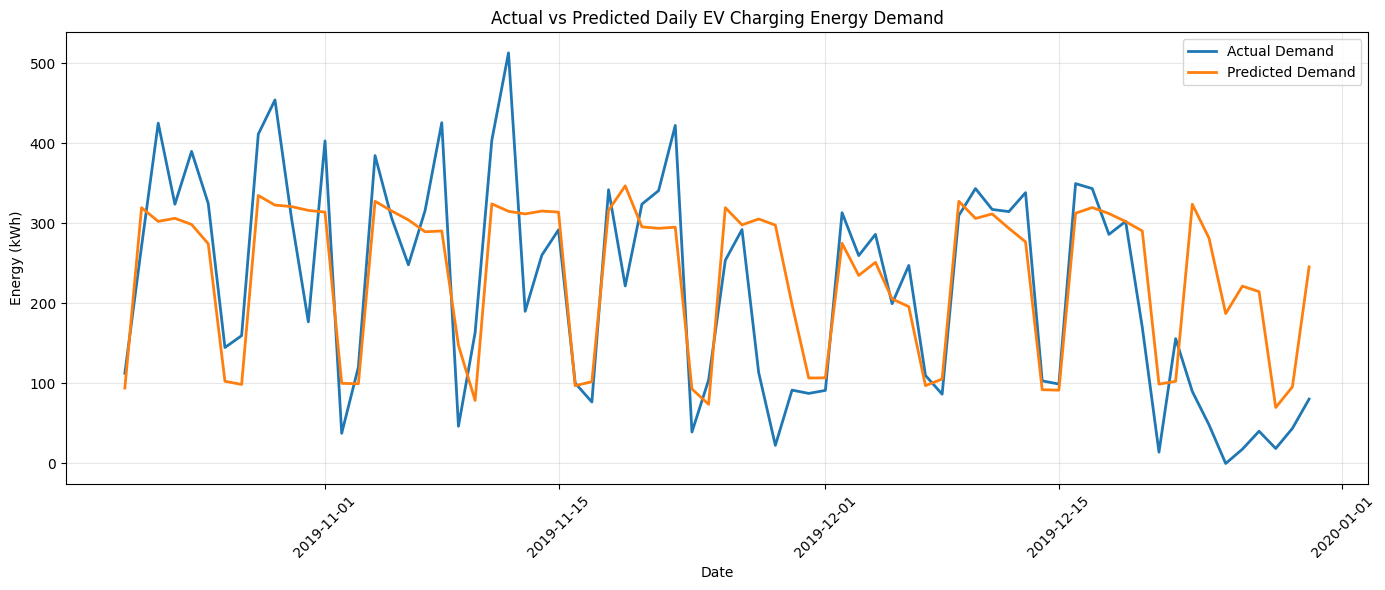

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    test_dates,
    gb_predictions,
    label="Predicted Demand",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.title("Actual vs Predicted Daily EV Charging Energy Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# Additional historical features
daily["energy_lag_14"] = daily["total_energy_kWh"].shift(14)

daily["energy_rolling_3"] = (
    daily["total_energy_kWh"]
    .shift(1)
    .rolling(3)
    .mean()
)

daily["energy_rolling_14"] = (
    daily["total_energy_kWh"]
    .shift(1)
    .rolling(14)
    .mean()
)

# Recent variability
daily["energy_std_7"] = (
    daily["total_energy_kWh"]
    .shift(1)
    .rolling(7)
    .std()
)

# Cyclical representation of day of week
daily["dow_sin"] = np.sin(2 * np.pi * daily["day_of_week"] / 7)
daily["dow_cos"] = np.cos(2 * np.pi * daily["day_of_week"] / 7)

# Cyclical representation of annual season
daily["day_of_year"] = daily["date"].dt.dayofyear

daily["year_sin"] = np.sin(
    2 * np.pi * daily["day_of_year"] / 365.25
)

daily["year_cos"] = np.cos(
    2 * np.pi * daily["day_of_year"] / 365.25
)

improved_features = [
    "day_of_week",
    "month",
    "is_weekend",
    "energy_lag_1",
    "energy_lag_7",
    "energy_lag_14",
    "energy_rolling_3",
    "energy_rolling_7",
    "energy_rolling_14",
    "energy_std_7",
    "dow_sin",
    "dow_cos",
    "year_sin",
    "year_cos"
]

improved_data = daily.dropna(subset=improved_features).copy()

print("Improved ML dataset shape:", improved_data.shape)
print("Number of features:", len(improved_features))

improved_data[
    ["date", "total_energy_kWh"] + improved_features
].head()

Improved ML dataset shape: (350, 18)
Number of features: 14


,date,total_energy_kWh,day_of_week,month,is_weekend,energy_lag_1,energy_lag_7,energy_lag_14,energy_rolling_3,energy_rolling_7,energy_rolling_14,energy_std_7,dow_sin,dow_cos,year_sin,year_cos
14,2019-01-15,526.676,1,1,0,490.458,387.251,48.802,301.707667,323.823000,306.084214,105.713245,0.781831,0.623490,0.255182,0.966893
15,2019-01-16,399.736,2,1,0,526.676,344.216,487.445,427.524333,343.740857,340.218071,130.000591,0.974928,-0.222521,0.271777,0.962360
16,2019-01-17,422.200,3,1,0,399.736,335.086,329.244,472.290000,351.672286,333.953143,131.716741,0.433884,-0.900969,0.288291,0.957543
17,2019-01-18,580.197,4,1,0,422.200,295.085,318.916,449.537333,364.117143,340.592857,133.984285,-0.433884,-0.900969,0.304719,0.952442
18,2019-01-19,224.115,5,1,1,580.197,149.226,93.990,467.377667,404.847429,359.255786,151.670205,-0.974928,-0.222521,0.321058,0.947060


In [15]:
# Keep the SAME test period as before for a fair comparison
train_improved = improved_data[
    improved_data["date"] < "2019-10-20"
].copy()

test_improved = improved_data[
    improved_data["date"] >= "2019-10-20"
].copy()

X_train_improved = train_improved[improved_features]
y_train_improved = train_improved["total_energy_kWh"]

X_test_improved = test_improved[improved_features]
y_test_improved = test_improved["total_energy_kWh"]

print("Training samples:", len(X_train_improved))
print("Testing samples:", len(X_test_improved))

# Train improved Gradient Boosting model
gb_improved = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=3,
    random_state=42
)

gb_improved.fit(X_train_improved, y_train_improved)

improved_predictions = gb_improved.predict(X_test_improved)

# Evaluate
improved_mae = mean_absolute_error(
    y_test_improved, improved_predictions
)

improved_rmse = np.sqrt(
    mean_squared_error(y_test_improved, improved_predictions)
)

improved_r2 = r2_score(
    y_test_improved, improved_predictions
)

print("\nImproved Gradient Boosting")
print("--------------------------")
print(f"MAE:  {improved_mae:.2f} kWh")
print(f"RMSE: {improved_rmse:.2f} kWh")
print(f"R²:   {improved_r2:.3f}")

Training samples: 278
Testing samples: 72

Improved Gradient Boosting
--------------------------
MAE:  103.07 kWh
RMSE: 142.68 kWh
R²:   -0.135


In [16]:
results = pd.DataFrame({
    "date": test_dates.values,
    "actual_kWh": y_test.values,
    "predicted_kWh": gb_predictions
})

results["absolute_error"] = abs(
    results["actual_kWh"] - results["predicted_kWh"]
)

results["month"] = pd.to_datetime(results["date"]).dt.month

monthly_errors = (
    results.groupby("month")
    .agg(
        days=("date", "count"),
        actual_mean=("actual_kWh", "mean"),
        predicted_mean=("predicted_kWh", "mean"),
        MAE=("absolute_error", "mean")
    )
)

print(monthly_errors.round(2))

print("\n10 largest prediction errors:")
print(
    results.nlargest(10, "absolute_error")[
        ["date", "actual_kWh", "predicted_kWh", "absolute_error"]
    ].round(2)
)

       days  actual_mean  predicted_mean    MAE
month                                          
10       12       291.69          257.68  67.92
11       30       231.50          242.97  75.00
12       30       179.40          218.41  67.03

10 largest prediction errors:
         date  actual_kWh  predicted_kWh  absolute_error
39 2019-11-28       22.62         297.82          275.21
64 2019-12-23       89.90         323.94          234.05
65 2019-12-24       48.29         281.53          233.24
67 2019-12-26       17.79         221.59          203.80
23 2019-11-12      513.07         315.08          197.99
38 2019-11-27      113.63         305.47          191.84
66 2019-12-25        0.00         187.28          187.28
68 2019-12-27       40.28         214.71          174.43
71 2019-12-30       80.46         245.56          165.10
11 2019-10-31      176.94         316.21          139.28


C:\Users\Deandra Fernandes\AppData\Local\Temp\ipykernel_29372\595085547.py:29: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


In [17]:
# US federal holiday dates relevant to the 2019 dataset
holiday_dates = pd.to_datetime([
    "2019-01-01",
    "2019-01-21",
    "2019-02-18",
    "2019-05-27",
    "2019-07-04",
    "2019-09-02",
    "2019-10-14",
    "2019-11-11",
    "2019-11-28",
    "2019-12-25"
])

daily["is_holiday"] = (
    daily["date"].isin(holiday_dates)
).astype(int)

print("Number of holidays marked:", daily["is_holiday"].sum())

print(
    daily[daily["is_holiday"] == 1][
        ["date", "total_energy_kWh", "is_holiday"]
    ]
)

Number of holidays marked: 10
          date  total_energy_kWh  is_holiday
0   2019-01-01         48.802000           1
20  2019-01-21        162.045000           1
48  2019-02-18        218.713000           1
146 2019-05-27         96.119000           1
184 2019-07-04         40.653000           1
244 2019-09-02        167.734000           1
286 2019-10-14        340.276000           1
314 2019-11-11        403.729214           1
331 2019-11-28         22.616000           1
358 2019-12-25          0.000000           1


In [18]:
holiday_features = [
    "day_of_week",
    "month",
    "is_weekend",
    "energy_lag_1",
    "energy_lag_7",
    "energy_rolling_7",
    "is_holiday"
]

# Same usable rows and exact same test period
holiday_data = daily.dropna(subset=holiday_features).copy()

train_holiday = holiday_data[
    holiday_data["date"] < "2019-10-20"
].copy()

test_holiday = holiday_data[
    holiday_data["date"] >= "2019-10-20"
].copy()

X_train_holiday = train_holiday[holiday_features]
y_train_holiday = train_holiday["total_energy_kWh"]

X_test_holiday = test_holiday[holiday_features]
y_test_holiday = test_holiday["total_energy_kWh"]

print("Training samples:", len(X_train_holiday))
print("Testing samples:", len(X_test_holiday))

# Train
gb_holiday = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=3,
    random_state=42
)

gb_holiday.fit(X_train_holiday, y_train_holiday)

holiday_predictions = gb_holiday.predict(X_test_holiday)

# Evaluate
holiday_mae = mean_absolute_error(
    y_test_holiday,
    holiday_predictions
)

holiday_rmse = np.sqrt(
    mean_squared_error(
        y_test_holiday,
        holiday_predictions
    )
)

holiday_r2 = r2_score(
    y_test_holiday,
    holiday_predictions
)

print("\nGradient Boosting + Holiday Feature")
print("-----------------------------------")
print(f"MAE:  {holiday_mae:.2f} kWh")
print(f"RMSE: {holiday_rmse:.2f} kWh")
print(f"R²:   {holiday_r2:.3f}")

Training samples: 285
Testing samples: 72

Gradient Boosting + Holiday Feature
-----------------------------------
MAE:  69.34 kWh
RMSE: 94.27 kWh
R²:   0.505


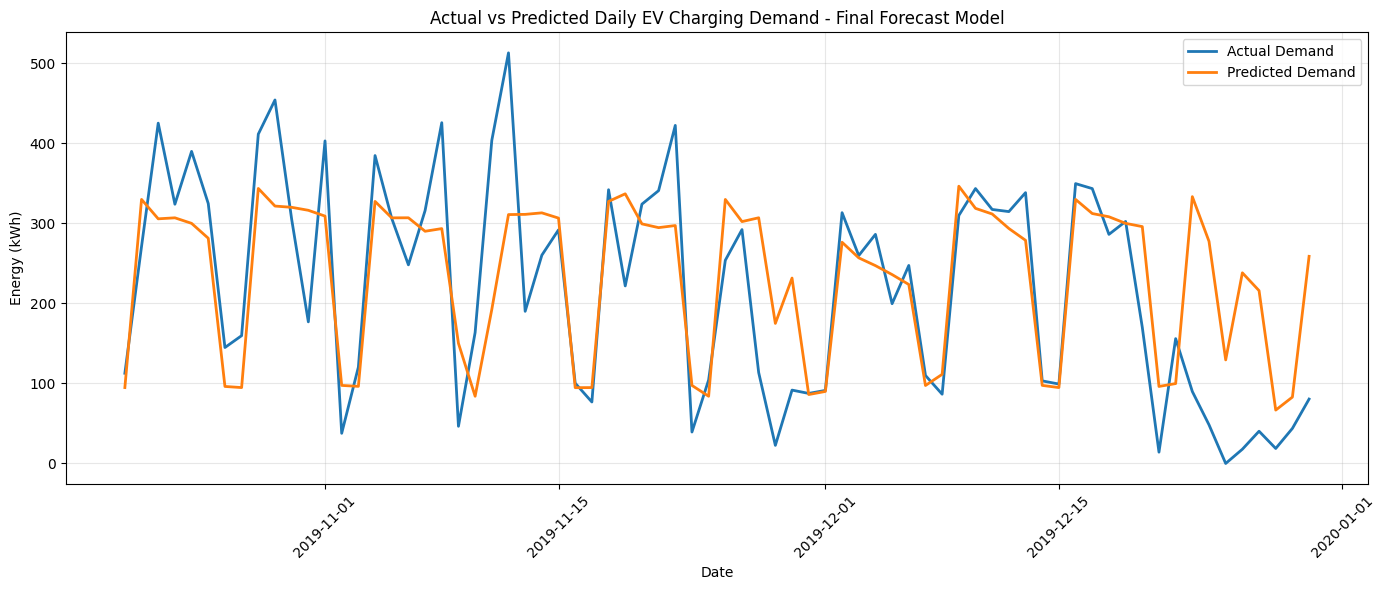

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_holiday["date"],
    y_test_holiday,
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    test_holiday["date"],
    holiday_predictions,
    label="Predicted Demand",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.title("Actual vs Predicted Daily EV Charging Demand - Final Forecast Model")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
from sklearn.base import BaseEstimator

models_found = {}

for name, obj in list(globals().items()):
    if isinstance(obj, BaseEstimator):
        models_found[name] = type(obj).__name__

models_found

{'linear_model': 'LinearRegression',
 'rf_model': 'RandomForestRegressor',
 'gb_model': 'GradientBoostingRegressor',
 'gb_improved': 'GradientBoostingRegressor',
 'gb_holiday': 'GradientBoostingRegressor'}

In [22]:
import pickle
import json
from pathlib import Path

# ============================================================
# SAVE FINAL FORECASTING MODEL
# ============================================================

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

# Final holiday-aware Gradient Boosting model
MODEL_PATH = MODEL_DIR / "demand_forecast_gb_holiday.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(gb_holiday, file)


# ============================================================
# SAVE MODEL METADATA
# ============================================================

feature_names = [
    "day_of_week",
    "month",
    "is_weekend",
    "energy_lag_1",
    "energy_lag_7",
    "energy_rolling_7",
    "is_holiday"
]

metadata = {
    "model_name": "GradientBoostingRegressor",
    "target": "daily_session_associated_energy_kwh",
    "features": feature_names,
    "mae_kwh": 69.34,
    "rmse_kwh": 94.27,
    "r2": 0.505,
    "training_method": "chronological_80_20_split",
    "notes": (
        "Forecasts daily session-associated energy demand. "
        "This is not exact meter-measured site load."
    )
}

METADATA_PATH = MODEL_DIR / "demand_forecast_metadata.json"

with open(METADATA_PATH, "w") as file:
    json.dump(metadata, file, indent=4)


# ============================================================
# VERIFY SAVED FILES
# ============================================================

print("MODEL SAVED SUCCESSFULLY")
print("--------------------------------")
print("Model:", MODEL_PATH)
print("Metadata:", METADATA_PATH)
print()
print("Final model:", type(gb_holiday).__name__)
print("Number of input features:", gb_holiday.n_features_in_)
print("Expected features:", len(feature_names))

MODEL SAVED SUCCESSFULLY
--------------------------------
Model: ..\models\demand_forecast_gb_holiday.pkl
Metadata: ..\models\demand_forecast_metadata.json

Final model: GradientBoostingRegressor
Number of input features: 7
Expected features: 7


In [23]:
# ============================================================
# SAVE DAILY ENERGY HISTORY FOR THE FORECAST API
# ============================================================

from pathlib import Path

OUTPUT_DIR = Path("../Data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

forecast_history = daily[
    ["date", "daily_energy_kwh"]
].copy()

forecast_history.to_csv(
    OUTPUT_DIR / "daily_energy_history.csv",
    index=False
)

print("Saved: ../Data/processed/daily_energy_history.csv")
print("Rows:", len(forecast_history))
print()
print(forecast_history.tail(10))

KeyError: "['daily_energy_kwh'] not in index"

In [24]:
print(daily.columns.tolist())

['date', 'total_energy_kWh', 'sessions', 'day_of_week', 'month', 'is_weekend', 'energy_lag_1', 'energy_lag_7', 'energy_rolling_7', 'energy_lag_14', 'energy_rolling_3', 'energy_rolling_14', 'energy_std_7', 'dow_sin', 'dow_cos', 'day_of_year', 'year_sin', 'year_cos', 'is_holiday']


In [25]:
from pathlib import Path

# ============================================================
# SAVE DAILY ENERGY HISTORY FOR FORECAST API
# ============================================================

OUTPUT_DIR = Path("../Data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

forecast_history = daily[
    ["date", "total_energy_kWh"]
].copy()

# Cleaner name for backend/API use
forecast_history = forecast_history.rename(
    columns={
        "total_energy_kWh": "daily_energy_kwh"
    }
)

forecast_history.to_csv(
    OUTPUT_DIR / "daily_energy_history.csv",
    index=False
)

print("DAILY ENERGY HISTORY SAVED SUCCESSFULLY")
print("---------------------------------------")
print("Saved: ../Data/processed/daily_energy_history.csv")
print("Rows:", len(forecast_history))
print("Columns:", forecast_history.columns.tolist())
print()
print("Last 10 rows:")
print(forecast_history.tail(10))

DAILY ENERGY HISTORY SAVED SUCCESSFULLY
---------------------------------------
Saved: ../Data/processed/daily_energy_history.csv
Rows: 364
Columns: ['date', 'daily_energy_kwh']

Last 10 rows:
          date  daily_energy_kwh
354 2019-12-21            14.125
355 2019-12-22           155.978
356 2019-12-23            89.895
357 2019-12-24            48.288
358 2019-12-25             0.000
359 2019-12-26            17.791
360 2019-12-27            40.280
361 2019-12-28            18.728
362 2019-12-29            43.819
363 2019-12-30            80.456
